# EDA — Datos Intradía (1h) vs Diarios (Magnificent 7)

**Input intradía:** `data/raw/market_intraday/ALL_market_intraday_2024_2026.csv`  
**Input diario:** `data/clean/dataset_integrado.csv`  
**Período intradía:** 2024-04-03 → 2026-04-02 (≈2 años, granularidad 1h)  
**Empresas:** AAPL, AMZN, GOOGL, META, MSFT, NVDA, TSLA

Análisis de volatilidad a escala horaria: patrón U intradía, efecto día de la semana,
picos horarios extremos, comparación con la base diaria y variables forward.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import mannwhitneyu
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Rutas
BASE_DIR = Path('..').resolve()
FIGURAS  = BASE_DIR / 'docs' / 'figuras'
FIGURAS.mkdir(parents=True, exist_ok=True)

# Paleta consistente
TICKERS = ['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']
COLORES = dict(zip(TICKERS, sns.color_palette('tab10', 7)))

# Etiquetas legibles
HORAS_ET = {9: '09:30', 10: '10:30', 11: '11:30', 12: '12:30',
            13: '13:30', 14: '14:30', 15: '15:30'}
DIAS_SEMANA = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes'}

plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'savefig.bbox': 'tight'})
sns.set_style('whitegrid')

## 1. Carga de datos

In [2]:
# --- Datos intradía (1h) — desde el CSV raw actualizado ---
df = pd.read_csv(BASE_DIR / 'data' / 'raw' / 'market_intraday' / 'ALL_market_intraday_2024_2026.csv',
                 parse_dates=['datetime'])

# Columnas numéricas que pueden venir como texto
NUM_COLS = ['log_return_1h', 'vol_realized_6h', 'vol_realized_30h',
            'range_proxy_1h', 'abs_return', 'sq_return',
            'return_fwd_1h', 'return_fwd_3h', 'vol_fwd_6h']
for col in NUM_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Filtrar solo sesión regular (ya marcada en el script de descarga)
n_total = len(df)
df = df[df['es_sesion_regular'] == True].copy()
print(f'Barras fuera de sesión descartadas: {n_total - len(df):,}')

df['fecha'] = pd.to_datetime(df['date'])

print(f'\n=== Dataset intradía (sesión regular) ===')
print(f'Shape: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Período: {df.datetime.min()} → {df.datetime.max()}')
print(f'Barras por empresa: ~{df.groupby("ticker").size().median():.0f}')
print(f'Horas únicas (ET): {sorted(df.hora.unique())}')
print(f'Columnas nuevas: return_fwd_1h, return_fwd_3h, vol_fwd_6h, date, es_sesion_regular')

# --- Datos diarios (para comparación) ---
df_daily = pd.read_csv(BASE_DIR / 'data' / 'clean' / 'dataset_integrado.csv',
                       parse_dates=['date'])
fecha_min, fecha_max = df['fecha'].min(), df['fecha'].max()
df_daily = df_daily[(df_daily.date >= fecha_min) & (df_daily.date <= fecha_max)]

print(f'\n=== Dataset diario (mismo período) ===')
print(f'Shape: {df_daily.shape[0]:,} filas × {df_daily.shape[1]} columnas')

Barras fuera de sesión descartadas: 0

=== Dataset intradía (sesión regular) ===
Shape: 24,430 filas × 22 columnas
Período: 2024-04-03 09:30:00-04:00 → 2026-04-02 15:30:00-04:00
Barras por empresa: ~3490
Horas únicas (ET): [np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
Columnas nuevas: return_fwd_1h, return_fwd_3h, vol_fwd_6h, date, es_sesion_regular

=== Dataset diario (mismo período) ===
Shape: 3,514 filas × 39 columnas


## 2. Estadísticas descriptivas por empresa y hora del día

¿Qué horas concentran mayor volatilidad? Se espera un **patrón en U**:
alta en la apertura (09:30), descenso a mediodía, repunte al cierre (15:30).

Retorno absoluto medio (%) por empresa y hora ET:
         09:30   10:30   11:30   12:30   13:30   14:30   15:30
ticker                                                        
AAPL    0.9276  0.3891  0.3009  0.2892  0.2617  0.2535  0.2769
AMZN    1.1757  0.4273  0.3703  0.3241  0.3012  0.2710  0.2879
GOOGL   1.1529  0.4171  0.3628  0.3109  0.2853  0.2764  0.2764
META    1.2779  0.4874  0.3837  0.3546  0.3209  0.2982  0.3078
MSFT    0.8456  0.3243  0.2610  0.2475  0.2474  0.2046  0.2427
NVDA    1.8258  0.6434  0.5340  0.4745  0.4507  0.4162  0.4480
TSLA    2.2777  0.7837  0.6368  0.5879  0.5881  0.5540  0.5085


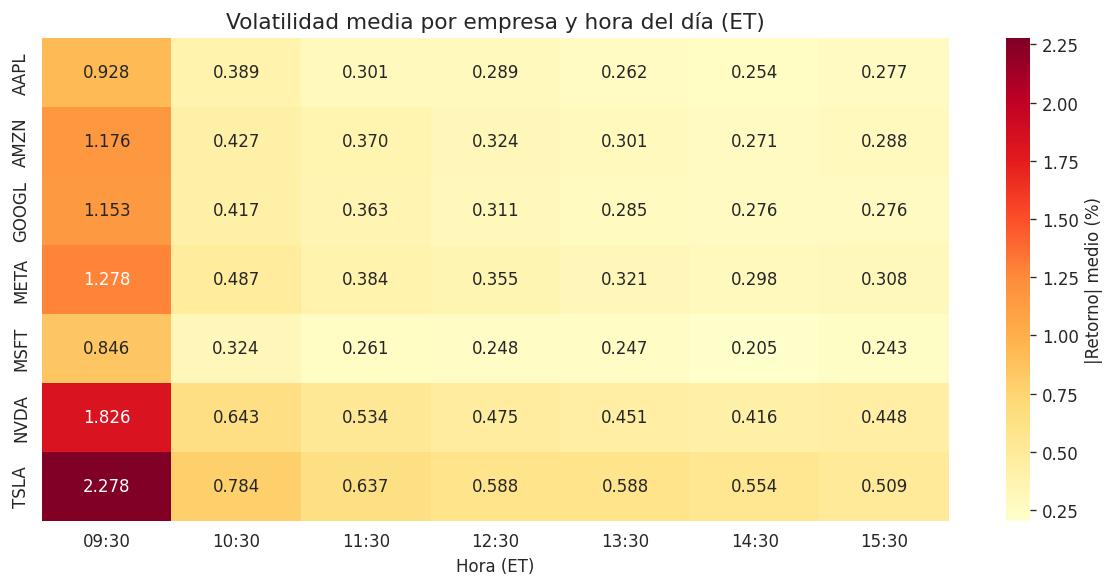

→ Guardado: docs/figuras/intraday_heatmap_hora_empresa.png


In [3]:
# Tabla pivotada: |retorno| medio por empresa × hora (en %)
pivot_vol = df.pivot_table(values='abs_return', index='ticker',
                           columns='hora', aggfunc='mean') * 100
pivot_vol.columns = [HORAS_ET.get(h, str(h)) for h in pivot_vol.columns]
print('Retorno absoluto medio (%) por empresa y hora ET:')
print(pivot_vol.round(4).to_string())

# --- Figura 1: Heatmap empresa × hora ---
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_vol, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': '|Retorno| medio (%)'}, ax=ax)
ax.set_title('Volatilidad media por empresa y hora del día (ET)', fontsize=13)
ax.set_xlabel('Hora (ET)')
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_heatmap_hora_empresa.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_heatmap_hora_empresa.png')

## 3. Patrón de volatilidad intradía — Efecto U

La literatura documenta que la volatilidad sigue un patrón en U durante la sesión:
alta en apertura, desciende a mediodía, repunta al cierre.

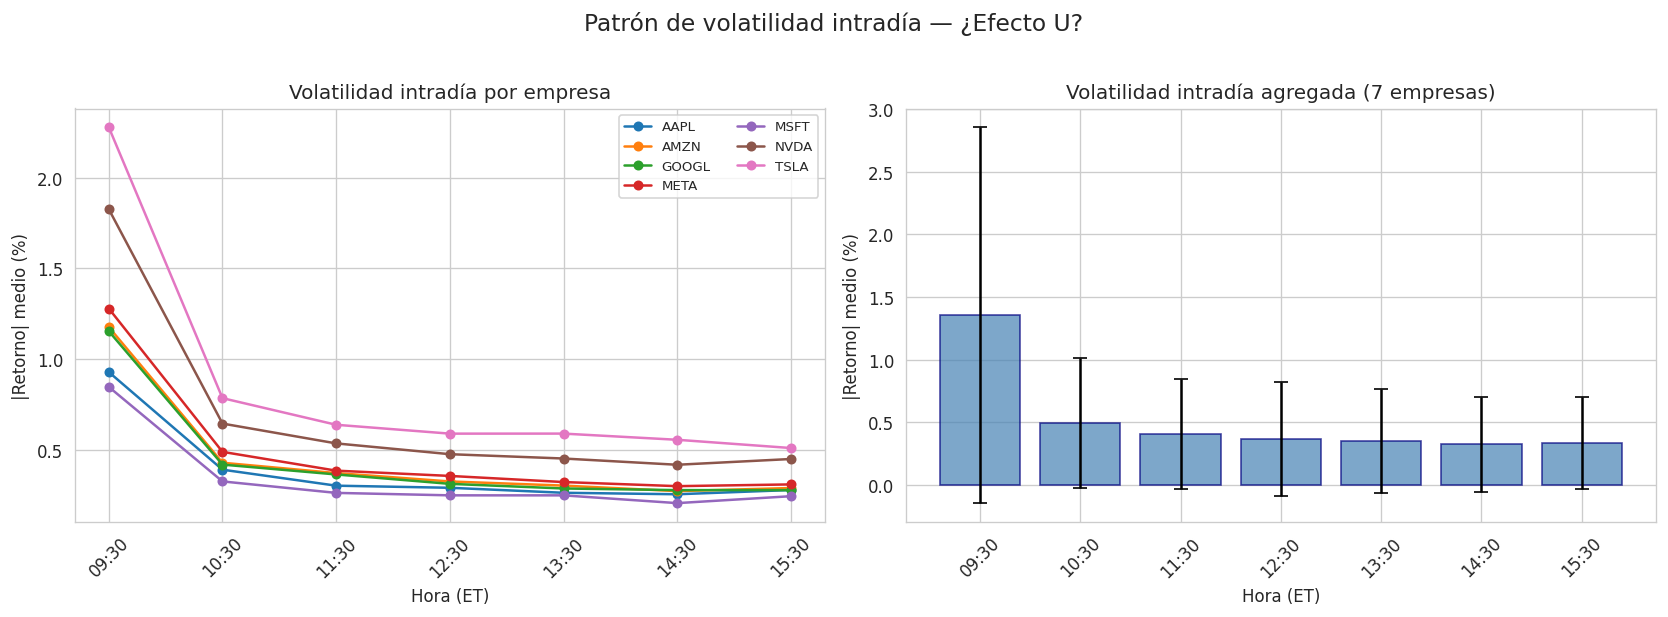

→ Guardado: docs/figuras/intraday_patron_U.png


In [4]:
# --- Figura 2: Patrón U — por empresa y agregado ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: por empresa
for ticker in TICKERS:
    g = df[df.ticker == ticker].groupby('hora')['abs_return'].mean() * 100
    axes[0].plot(g.index, g.values, 'o-', color=COLORES[ticker],
                 label=ticker, linewidth=1.5, markersize=5)
horas_sorted = sorted(df.hora.unique())
axes[0].set_xticks(horas_sorted)
axes[0].set_xticklabels([HORAS_ET.get(h, str(h)) for h in horas_sorted], rotation=45)
axes[0].set_xlabel('Hora (ET)')
axes[0].set_ylabel('|Retorno| medio (%)')
axes[0].set_title('Volatilidad intradía por empresa')
axes[0].legend(fontsize=8, ncol=2)

# Derecha: agregado con barras de error
agg = df.groupby('hora')['abs_return'].agg(['mean', 'std']) * 100
axes[1].bar(agg.index, agg['mean'], yerr=agg['std'], capsize=4,
            color='steelblue', alpha=0.7, edgecolor='navy')
axes[1].set_xticks(horas_sorted)
axes[1].set_xticklabels([HORAS_ET.get(h, str(h)) for h in horas_sorted], rotation=45)
axes[1].set_xlabel('Hora (ET)')
axes[1].set_ylabel('|Retorno| medio (%)')
axes[1].set_title('Volatilidad intradía agregada (7 empresas)')

fig.suptitle('Patrón de volatilidad intradía — ¿Efecto U?', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_patron_U.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_patron_U.png')

In [5]:
# Test estadístico: ¿apertura/cierre significativamente más volátiles que mediodía?
vol_extremos = df[df.hora.isin([9, 10, 15])]['abs_return'].dropna()
vol_medio    = df[df.hora.isin([12, 13])]['abs_return'].dropna()

stat, pval = mannwhitneyu(vol_extremos, vol_medio, alternative='greater')

print('Test Mann-Whitney U (apertura/cierre vs mediodía):')
print(f'  Media apertura/cierre: {vol_extremos.mean()*100:.4f}%')
print(f'  Media mediodía:        {vol_medio.mean()*100:.4f}%')
print(f'  Ratio:                 {vol_extremos.mean()/vol_medio.mean():.2f}x')
print(f'  U-statistic:           {stat:,.0f}')
print(f'  p-valor:               {pval:.2e}')
print(f'  → {"SÍ" if pval < 0.01 else "NO"} hay diferencia significativa (α=0.01)')

Test Mann-Whitney U (apertura/cierre vs mediodía):
  Media apertura/cierre: 0.7299%
  Media mediodía:        0.3603%
  Ratio:                 2.03x
  U-statistic:           45,427,166
  p-valor:               1.62e-168
  → SÍ hay diferencia significativa (α=0.01)


## 4. Patrón por día de la semana

¿Los lunes y viernes son más volátiles? Lunes acumula información del fin de semana;
viernes refleja ajustes de posiciones antes del cierre semanal.

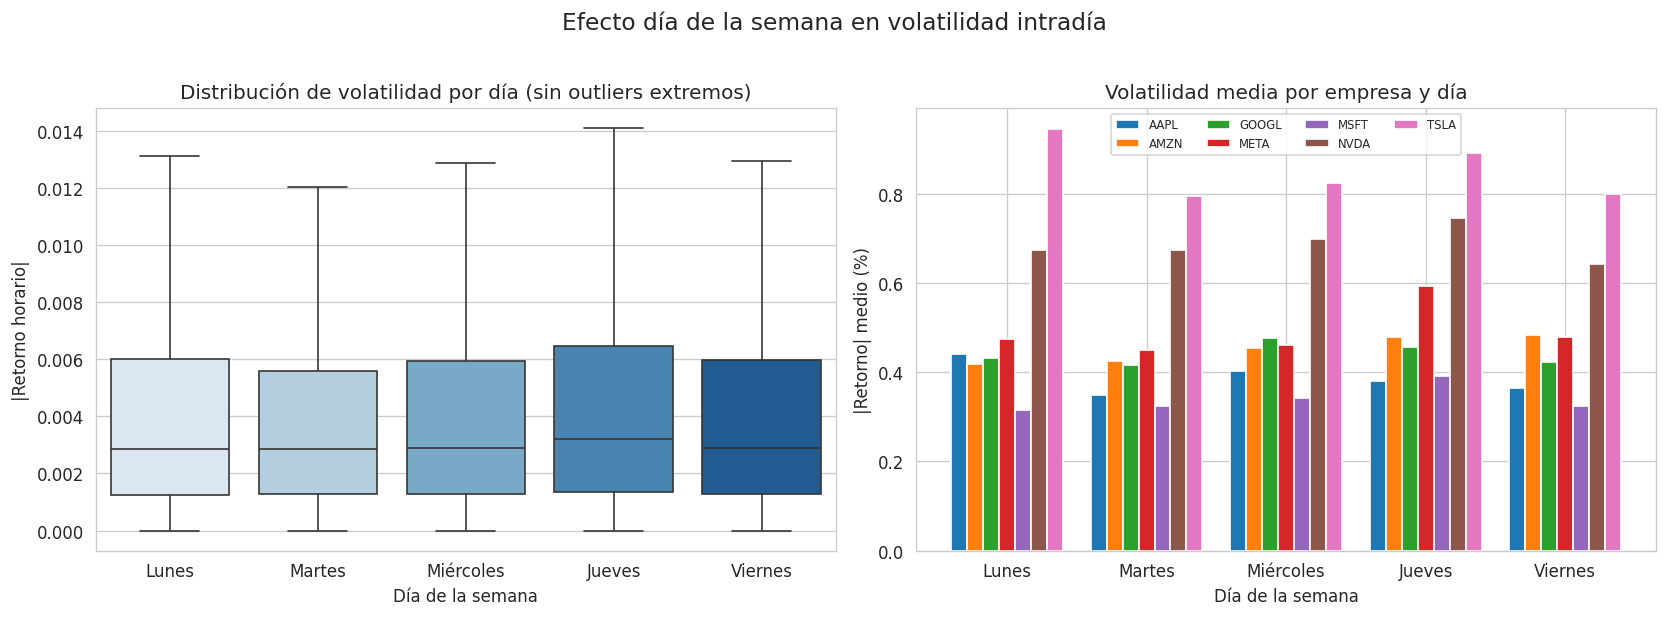

→ Guardado: docs/figuras/intraday_efecto_dia_semana.png


In [6]:
# --- Figura 3: Volatilidad por día de la semana ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Izquierda: boxplot agregado
df_box = df.copy()
df_box['dia_nombre'] = df_box['dia_semana'].map(DIAS_SEMANA)
orden_dias = [DIAS_SEMANA[d] for d in range(5)]

sns.boxplot(data=df_box, x='dia_nombre', y='abs_return',
            order=orden_dias, palette='Blues', showfliers=False, ax=axes[0])
axes[0].set_xlabel('Día de la semana')
axes[0].set_ylabel('|Retorno horario|')
axes[0].set_title('Distribución de volatilidad por día (sin outliers extremos)')

# Derecha: media por día y empresa
pivot_dia = df.pivot_table(values='abs_return', index='ticker',
                           columns='dia_semana', aggfunc='mean') * 100
pivot_dia.columns = [DIAS_SEMANA[d] for d in pivot_dia.columns]
pivot_dia.T.plot(kind='bar', ax=axes[1], color=[COLORES[t] for t in pivot_dia.index],
                 width=0.8, edgecolor='white')
axes[1].set_xlabel('Día de la semana')
axes[1].set_ylabel('|Retorno| medio (%)')
axes[1].set_title('Volatilidad media por empresa y día')
axes[1].legend(fontsize=7, ncol=4)
axes[1].tick_params(axis='x', rotation=0)

fig.suptitle('Efecto día de la semana en volatilidad intradía', fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_efecto_dia_semana.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_efecto_dia_semana.png')

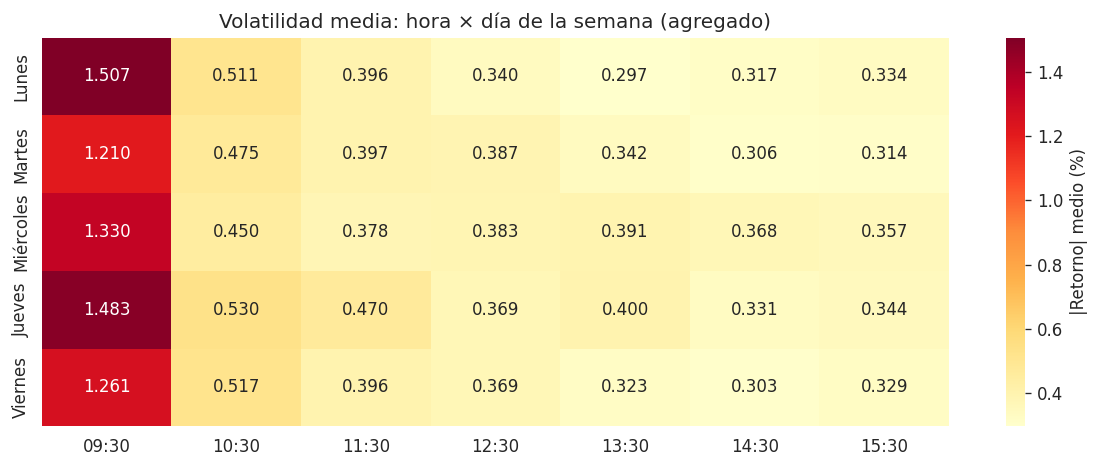

→ Guardado: docs/figuras/intraday_heatmap_hora_dia.png


In [7]:
# --- Figura 4: Heatmap hora × día (agregado 7 empresas) ---
pivot_hd = df.pivot_table(values='abs_return', index='dia_semana',
                          columns='hora', aggfunc='mean') * 100
pivot_hd.index = [DIAS_SEMANA[d] for d in pivot_hd.index]
pivot_hd.columns = [HORAS_ET.get(h, str(h)) for h in pivot_hd.columns]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pivot_hd, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': '|Retorno| medio (%)'}, ax=ax)
ax.set_title('Volatilidad media: hora × día de la semana (agregado)', fontsize=12)
ax.set_ylabel('')
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_heatmap_hora_dia.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_heatmap_hora_dia.png')

## 5. Comparación volatilidad horaria vs diaria

Agregamos la volatilidad horaria a nivel diario y la correlacionamos con la volatilidad
intradía diaria. ¿Los picos horarios anticipan los picos diarios?

In [8]:
# Agregar volatilidad intradía a nivel diario usando la columna 'date'
vol_agg = (df.groupby(['ticker', 'date'])
           .agg(vol_media_hora=('abs_return', 'mean'),
                vol_max_hora=('abs_return', 'max'),
                n_barras=('abs_return', 'count'))
           .reset_index())
vol_agg['date'] = pd.to_datetime(vol_agg['date'])

# Merge con datos diarios
comp = vol_agg.merge(
    df_daily[['date', 'ticker', 'vol_realized_5d', 'vol_intraday', 'abs_return']],
    on=['date', 'ticker'], how='inner', suffixes=('_hourly', '_daily'))

print(f'Observaciones emparejadas: {len(comp):,}')
print(f'\nCorrelación vol media horaria vs vol intradía diaria:')
for ticker in TICKERS:
    sub = comp[comp.ticker == ticker].dropna(subset=['vol_media_hora', 'vol_intraday'])
    r = sub['vol_media_hora'].corr(sub['vol_intraday'])
    print(f'  {ticker}: ρ = {r:.3f}')

Observaciones emparejadas: 3,514

Correlación vol media horaria vs vol intradía diaria:
  AAPL: ρ = 0.806
  AMZN: ρ = 0.657
  GOOGL: ρ = 0.720
  META: ρ = 0.693
  MSFT: ρ = 0.721
  NVDA: ρ = 0.760
  TSLA: ρ = 0.720


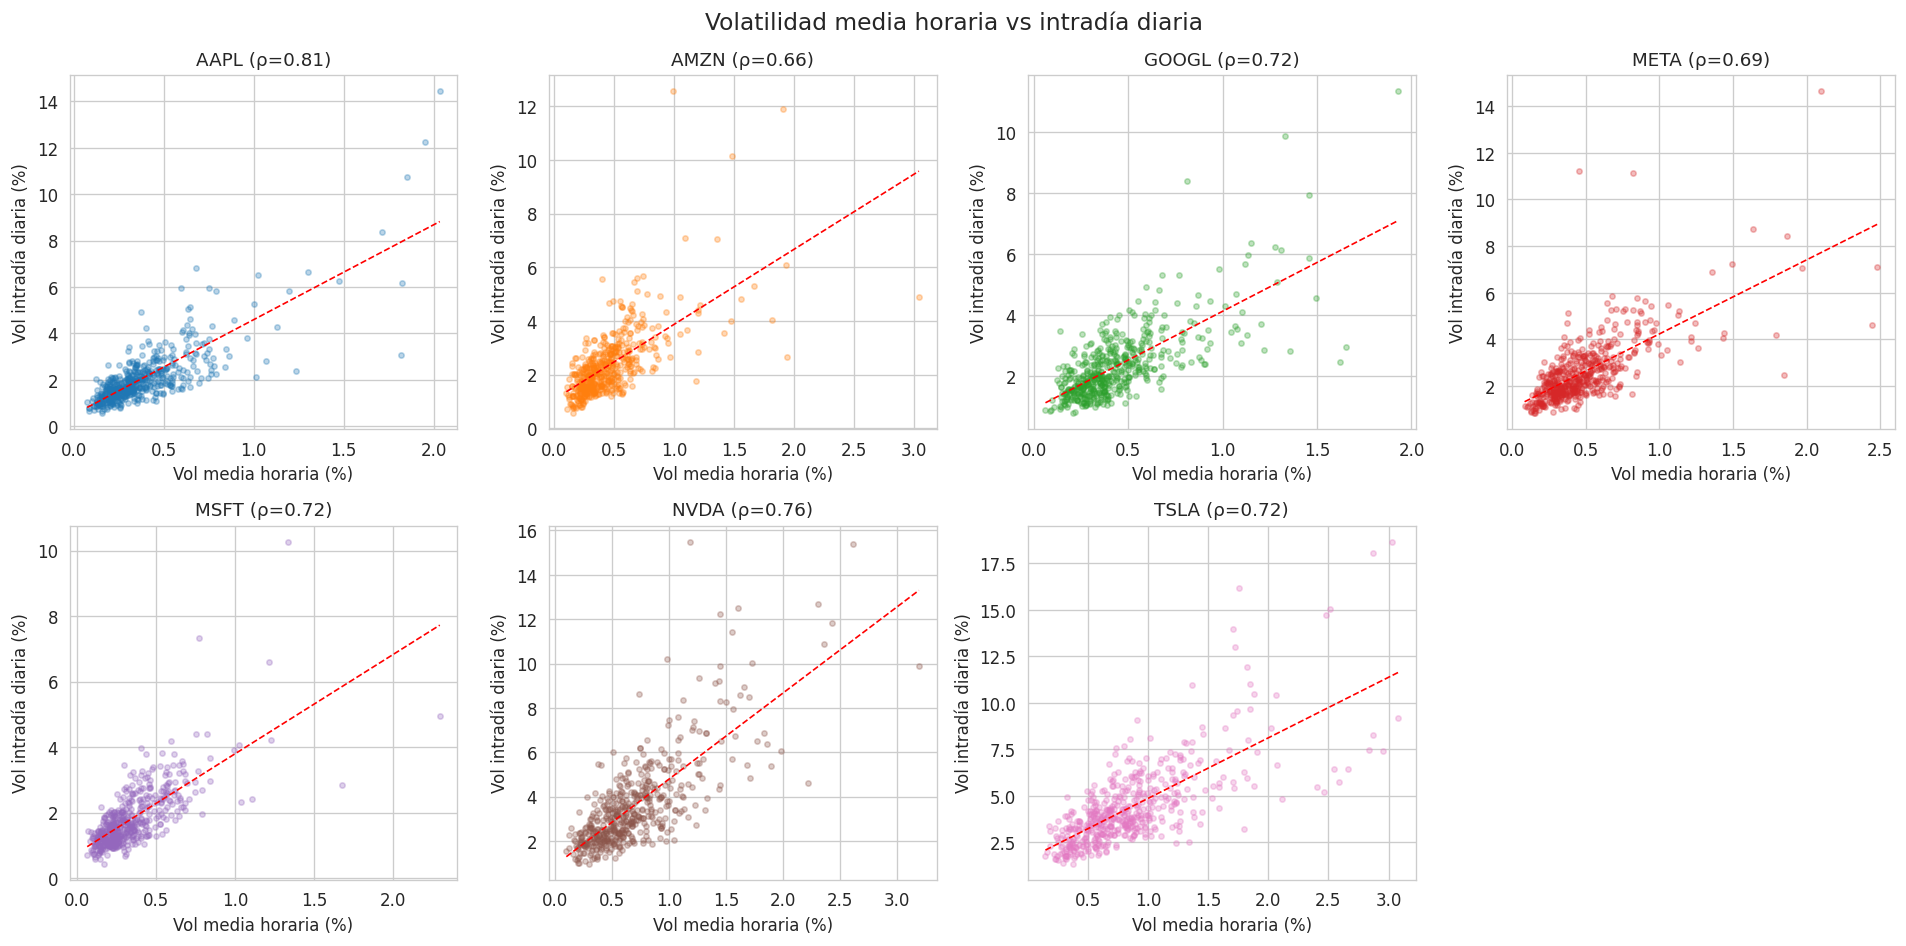

→ Guardado: docs/figuras/intraday_vs_diaria_scatter.png


In [9]:
# --- Figura 5: Scatter vol horaria vs vol diaria por empresa ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes_flat = axes.flatten()

for i, ticker in enumerate(TICKERS):
    sub = comp[comp.ticker == ticker].dropna(subset=['vol_media_hora', 'vol_intraday'])
    ax = axes_flat[i]
    ax.scatter(sub['vol_media_hora'] * 100, sub['vol_intraday'] * 100,
               alpha=0.3, s=10, color=COLORES[ticker])
    r = sub['vol_media_hora'].corr(sub['vol_intraday'])
    ax.set_title(f'{ticker} (ρ={r:.2f})', fontsize=11)
    ax.set_xlabel('Vol media horaria (%)')
    ax.set_ylabel('Vol intradía diaria (%)')
    # Línea de tendencia
    z = np.polyfit(sub['vol_media_hora'], sub['vol_intraday'], 1)
    x_line = np.linspace(sub['vol_media_hora'].min(), sub['vol_media_hora'].max(), 50)
    ax.plot(x_line * 100, np.polyval(z, x_line) * 100, 'r--', linewidth=1)

axes_flat[7].set_visible(False)
fig.suptitle('Volatilidad media horaria vs intradía diaria', fontsize=14)
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_vs_diaria_scatter.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_vs_diaria_scatter.png')

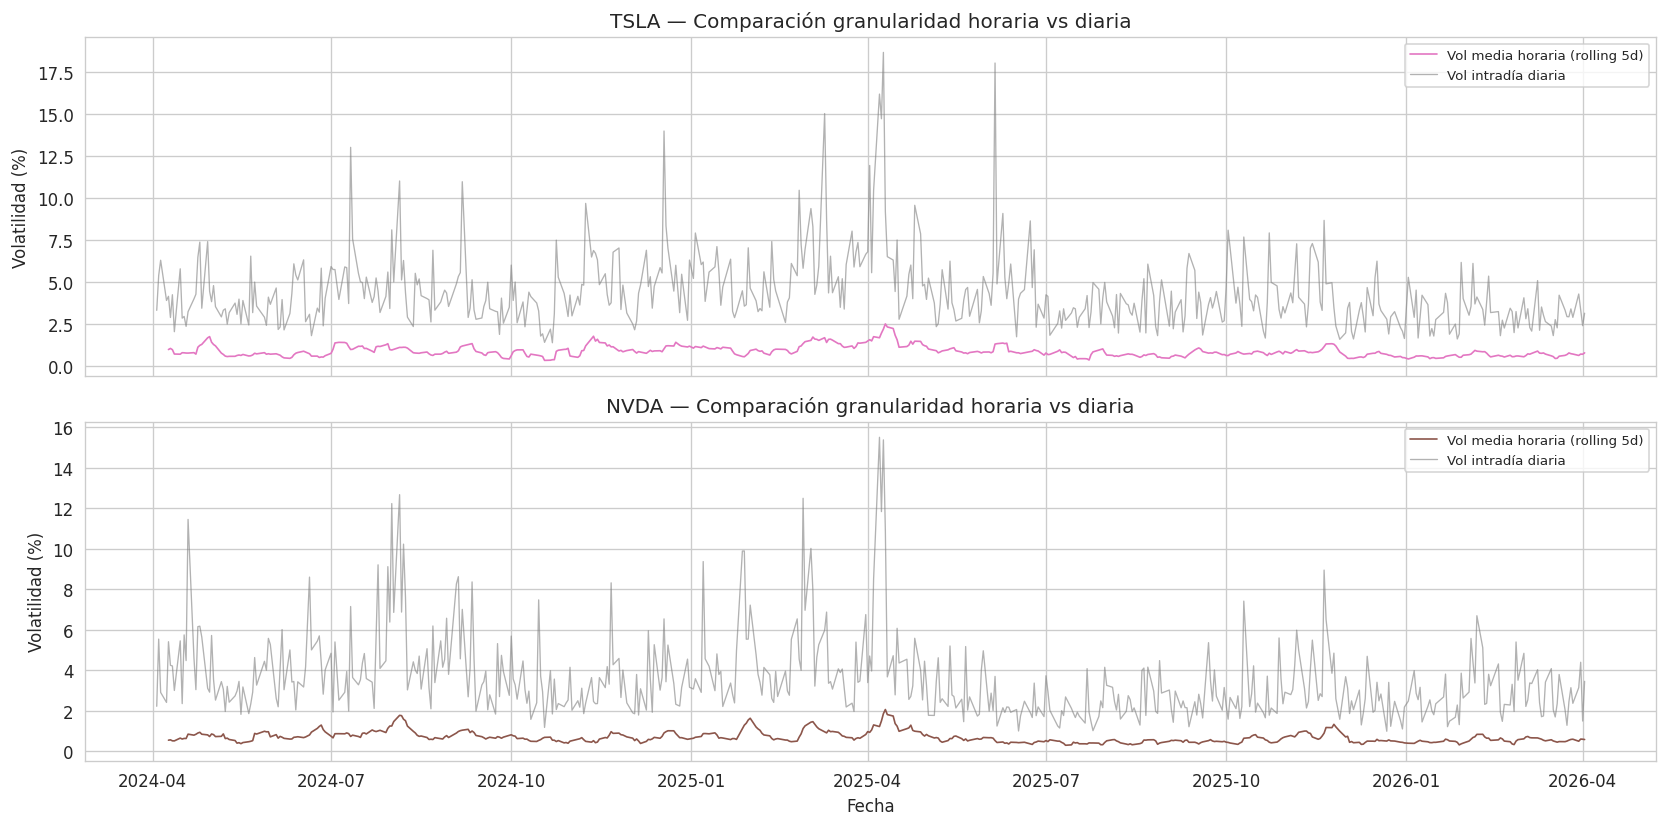

→ Guardado: docs/figuras/intraday_comparacion_temporal.png


In [10]:
# --- Figura 6: Series temporales comparadas — TSLA y NVDA ---
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

for i, ticker in enumerate(['TSLA', 'NVDA']):
    ax = axes[i]
    sub = comp[comp.ticker == ticker].sort_values('date')
    ax.plot(sub.date, sub.vol_media_hora.rolling(5).mean() * 100,
            color=COLORES[ticker], label='Vol media horaria (rolling 5d)', linewidth=1)
    ax.plot(sub.date, sub.vol_intraday * 100,
            color='gray', alpha=0.6, label='Vol intradía diaria', linewidth=0.8)
    ax.set_ylabel('Volatilidad (%)')
    ax.set_title(f'{ticker} — Comparación granularidad horaria vs diaria')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

axes[1].set_xlabel('Fecha')
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_comparacion_temporal.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_comparacion_temporal.png')

## 6. Top 10 horas más volátiles por empresa

Barras horarias con mayor movimiento absoluto, con fecha, hora ET y evento asociado.

In [11]:
# Eventos conocidos del período 2024-2026
EVENTOS = {
    '2024-04-19': 'Escalada Irán-Israel',
    '2024-07-24': 'Earnings TSLA/GOOGL',
    '2024-08-05': 'Carry trade Japón / crash global',
    '2024-09-03': 'Caída tech post-Labor Day',
    '2024-10-29': 'Earnings META Q3',
    '2024-10-31': 'Earnings MSFT/META',
    '2024-11-06': 'Elecciones EEUU (Trump)',
    '2025-01-27': 'DeepSeek crash — IA china',
    '2025-01-29': 'Earnings MSFT/META Q4',
    '2025-02-03': 'Aranceles Trump China/Canadá/México',
    '2025-02-05': 'Earnings GOOGL/AMZN',
    '2025-03-04': 'Escalada aranceles',
    '2025-03-10': 'Sell-off tech aranceles',
    '2025-04-03': 'Liberation Day aranceles',
    '2025-04-07': 'Crash aranceles recíprocos',
    '2025-04-09': 'Pausa aranceles 90 días (rebote)',
    '2025-04-28': 'Earnings AAPL/AMZN/META',
}

def buscar_evento(fecha_str):
    """Busca evento asociado a una fecha (±1 día)."""
    fecha = pd.to_datetime(fecha_str).date()
    for delta in [0, -1, 1]:
        f = (fecha + pd.Timedelta(days=delta)).isoformat()
        if f in EVENTOS:
            return EVENTOS[f]
    return ''

for ticker in TICKERS:
    sub = df[df.ticker == ticker].nlargest(10, 'abs_return')[
        ['datetime', 'hora', 'log_return_1h', 'abs_return', 'close']
    ].copy()
    sub['retorno_%'] = (sub['log_return_1h'] * 100).round(2)
    # Usar la columna 'date' (string) que ya existe, en vez de .dt accessor
    sub['fecha'] = df.loc[sub.index, 'date']
    sub['hora_et'] = sub['hora'].map(HORAS_ET)
    sub['evento'] = sub['fecha'].apply(buscar_evento)
    print(f'\n{"="*70}')
    print(f'TOP 10 HORAS MÁS VOLÁTILES — {ticker}')
    print(f'{"="*70}')
    print(sub[['fecha', 'hora_et', 'retorno_%', 'evento']].to_string(index=False))


TOP 10 HORAS MÁS VOLÁTILES — AAPL
     fecha hora_et  retorno_%                           evento
2025-04-03   09:30      -8.46         Liberation Day aranceles
2024-05-03   09:30       6.21                                 
2024-08-05   09:30      -5.53 Carry trade Japón / crash global
2025-05-12   09:30       5.21                                 
2025-04-09   12:30       4.86 Pausa aranceles 90 días (rebote)
2025-04-08   12:30      -4.63       Crash aranceles recíprocos
2025-03-10   09:30      -4.50          Sell-off tech aranceles
2025-04-08   09:30       4.17       Crash aranceles recíprocos
2025-04-04   09:30      -4.11         Liberation Day aranceles
2024-06-11   09:30       3.94                                 

TOP 10 HORAS MÁS VOLÁTILES — AMZN
     fecha hora_et  retorno_%                           evento
2024-08-02   09:30     -13.14                                 
2025-10-31   09:30      10.14                                 
2025-04-03   09:30      -8.53         Liberation

## 7. Series temporales vol_realized_6h — TSLA y NVDA con eventos

Las dos empresas más volátiles del grupo. Volatilidad realizada a 6 barras
(≈1 día de negociación) con eventos de mercado marcados.

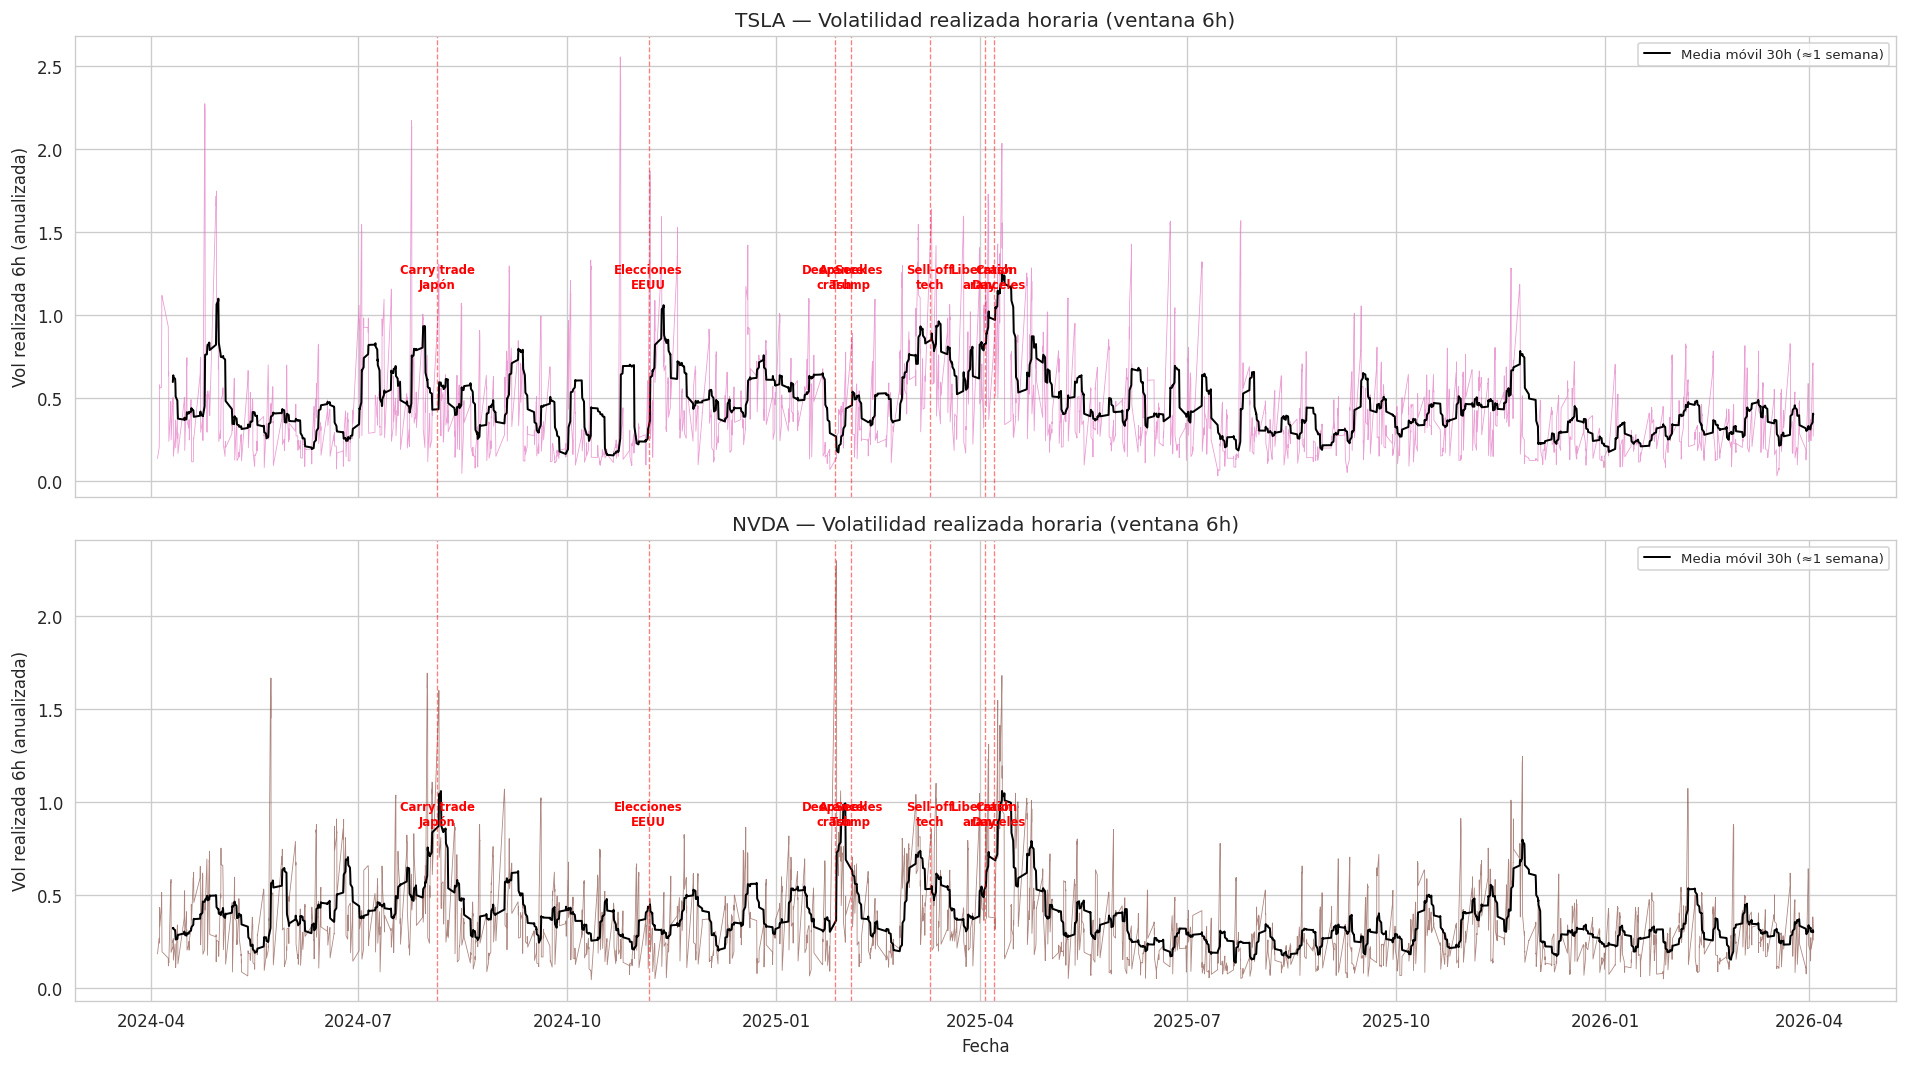

→ Guardado: docs/figuras/intraday_vol6h_TSLA_NVDA_eventos.png


In [12]:
# --- Figura 7: Series vol_realized_6h para TSLA y NVDA con eventos ---
EVENTOS_PLOT = {
    pd.Timestamp('2024-08-05'): 'Carry trade\nJapón',
    pd.Timestamp('2024-11-06'): 'Elecciones\nEEUU',
    pd.Timestamp('2025-01-27'): 'DeepSeek\ncrash',
    pd.Timestamp('2025-02-03'): 'Aranceles\nTrump',
    pd.Timestamp('2025-03-10'): 'Sell-off\ntech',
    pd.Timestamp('2025-04-03'): 'Liberation\nDay',
    pd.Timestamp('2025-04-07'): 'Crash\naranceles',
}

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

for i, ticker in enumerate(['TSLA', 'NVDA']):
    ax = axes[i]
    sub = df[(df.ticker == ticker) & df.vol_realized_6h.notna()].sort_values('datetime')

    ax.plot(sub.datetime, sub.vol_realized_6h, color=COLORES[ticker],
            linewidth=0.5, alpha=0.7)
    # Media móvil semanal (30 barras ≈ 5 días)
    ax.plot(sub.datetime, sub.vol_realized_6h.rolling(30).mean(),
            color='black', linewidth=1.2, label='Media móvil 30h (≈1 semana)')

    # Marcar eventos
    ymax = sub.vol_realized_6h.quantile(0.95)
    for fecha_ev, etiqueta in EVENTOS_PLOT.items():
        ax.axvline(fecha_ev, color='red', alpha=0.5, linewidth=0.8, linestyle='--')
        ax.text(fecha_ev, ymax * 1.02, etiqueta, fontsize=7,
                ha='center', va='bottom', color='red', fontweight='bold')

    ax.set_ylabel('Vol realizada 6h (anualizada)')
    ax.set_title(f'{ticker} — Volatilidad realizada horaria (ventana 6h)', fontsize=12)
    ax.legend(fontsize=8)

axes[1].set_xlabel('Fecha')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_vol6h_TSLA_NVDA_eventos.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_vol6h_TSLA_NVDA_eventos.png')

## 8. Variables forward — distribución y correlaciones

Las nuevas columnas `return_fwd_1h`, `return_fwd_3h` y `vol_fwd_6h` son los
targets predictivos. Verificamos su distribución y relación con las features actuales.

Estadísticas de variables forward (todos los tickers):
       return_fwd_1h  return_fwd_3h    vol_fwd_6h
count   24423.000000   24409.000000  24388.000000
mean        0.000109       0.000323      0.290141
std         0.009338       0.015953      0.244707
min        -0.139523      -0.175690      0.014962
25%        -0.002821      -0.005800      0.136889
50%         0.000098       0.000329      0.218420
75%         0.003030       0.006231      0.360015
max         0.153294       0.177188      2.554081

Nulos por variable forward:
  return_fwd_1h: 7 (0.0%)
  return_fwd_3h: 21 (0.1%)
  vol_fwd_6h: 42 (0.2%)


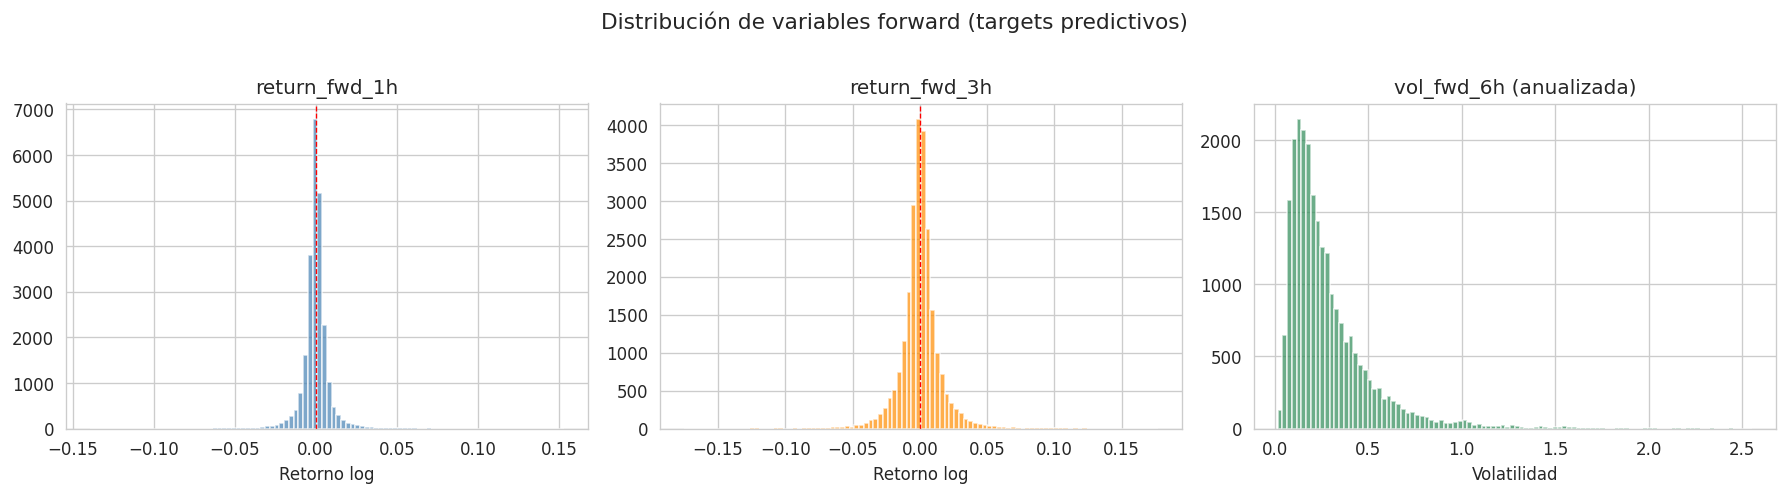

→ Guardado: docs/figuras/intraday_distribucion_forward.png


In [13]:
# Estadísticas de las variables forward
fwd_cols = ['return_fwd_1h', 'return_fwd_3h', 'vol_fwd_6h']
print('Estadísticas de variables forward (todos los tickers):')
print(df[fwd_cols].describe().round(6).to_string())

print(f'\nNulos por variable forward:')
for col in fwd_cols:
    n = df[col].isna().sum()
    print(f'  {col}: {n:,} ({100*n/len(df):.1f}%)')

# --- Figura 8: Distribución de targets forward ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['return_fwd_1h'].dropna(), bins=100, color='steelblue',
             alpha=0.7, edgecolor='white')
axes[0].set_title('return_fwd_1h')
axes[0].set_xlabel('Retorno log')
axes[0].axvline(0, color='red', linestyle='--', linewidth=0.8)

axes[1].hist(df['return_fwd_3h'].dropna(), bins=100, color='darkorange',
             alpha=0.7, edgecolor='white')
axes[1].set_title('return_fwd_3h')
axes[1].set_xlabel('Retorno log')
axes[1].axvline(0, color='red', linestyle='--', linewidth=0.8)

axes[2].hist(df['vol_fwd_6h'].dropna(), bins=100, color='seagreen',
             alpha=0.7, edgecolor='white')
axes[2].set_title('vol_fwd_6h (anualizada)')
axes[2].set_xlabel('Volatilidad')

fig.suptitle('Distribución de variables forward (targets predictivos)', fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_distribucion_forward.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_distribucion_forward.png')

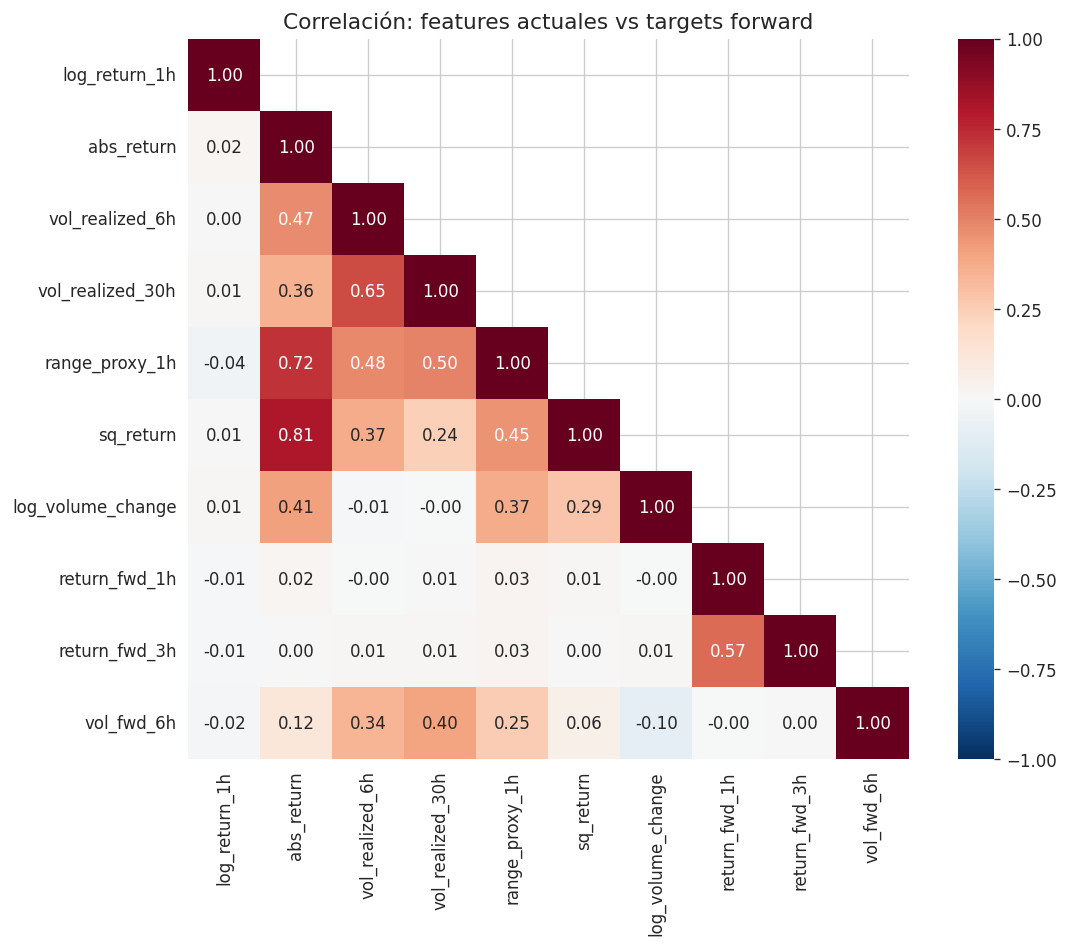

→ Guardado: docs/figuras/intraday_correlacion_features_forward.png

Correlación con vol_fwd_6h (target principal):
  log_return_1h            : -0.017
  abs_return               : +0.120
  vol_realized_6h          : +0.337
  vol_realized_30h         : +0.400
  range_proxy_1h           : +0.251
  sq_return                : +0.061
  log_volume_change        : -0.099


In [14]:
# --- Figura 9: Correlación features actuales vs targets forward ---
corr_cols = ['log_return_1h', 'abs_return', 'vol_realized_6h', 'vol_realized_30h',
             'range_proxy_1h', 'sq_return', 'log_volume_change',
             'return_fwd_1h', 'return_fwd_3h', 'vol_fwd_6h']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Correlación: features actuales vs targets forward', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURAS / 'intraday_correlacion_features_forward.png')
plt.show()
print('→ Guardado: docs/figuras/intraday_correlacion_features_forward.png')

# Resumen de correlaciones clave con vol_fwd_6h
print('\nCorrelación con vol_fwd_6h (target principal):')
for col in corr_cols[:-3]:
    r = corr_matrix.loc[col, 'vol_fwd_6h']
    print(f'  {col:25s}: {r:+.3f}')

## 9. Resumen cuantitativo

In [15]:
# Resumen: hora más y menos volátil por empresa
print('=' * 70)
print('RESUMEN: Hora más y menos volátil por empresa')
print('=' * 70)

for ticker in TICKERS:
    sub = df[df.ticker == ticker].groupby('hora')['abs_return'].mean()
    hora_max, hora_min = sub.idxmax(), sub.idxmin()
    ratio = sub.max() / sub.min()
    print(f'{ticker}: Más volátil={HORAS_ET[hora_max]} ({sub.max()*100:.3f}%), '
          f'Menos volátil={HORAS_ET[hora_min]} ({sub.min()*100:.3f}%), '
          f'Ratio={ratio:.1f}x')

print('\n' + '=' * 70)
print('RESUMEN: Día más volátil por empresa')
print('=' * 70)

for ticker in TICKERS:
    sub = df[df.ticker == ticker].groupby('dia_semana')['abs_return'].mean()
    dia_max, dia_min = sub.idxmax(), sub.idxmin()
    print(f'{ticker}: Más volátil={DIAS_SEMANA[dia_max]} ({sub.max()*100:.3f}%), '
          f'Menos volátil={DIAS_SEMANA[dia_min]} ({sub.min()*100:.3f}%)')

# Figuras generadas
print('\n' + '=' * 70)
print('FIGURAS GENERADAS')
print('=' * 70)
figuras = [
    'intraday_heatmap_hora_empresa.png',
    'intraday_patron_U.png',
    'intraday_efecto_dia_semana.png',
    'intraday_heatmap_hora_dia.png',
    'intraday_vs_diaria_scatter.png',
    'intraday_comparacion_temporal.png',
    'intraday_vol6h_TSLA_NVDA_eventos.png',
    'intraday_distribucion_forward.png',
    'intraday_correlacion_features_forward.png',
]
for f in figuras:
    existe = (FIGURAS / f).exists()
    print(f'  {"OK" if existe else "FALTA"} docs/figuras/{f}')

print(f'\nColumnas del dataset: {list(df.columns)}')

RESUMEN: Hora más y menos volátil por empresa
AAPL: Más volátil=09:30 (0.928%), Menos volátil=14:30 (0.254%), Ratio=3.7x
AMZN: Más volátil=09:30 (1.176%), Menos volátil=14:30 (0.271%), Ratio=4.3x
GOOGL: Más volátil=09:30 (1.153%), Menos volátil=14:30 (0.276%), Ratio=4.2x
META: Más volátil=09:30 (1.278%), Menos volátil=14:30 (0.298%), Ratio=4.3x
MSFT: Más volátil=09:30 (0.846%), Menos volátil=14:30 (0.205%), Ratio=4.1x
NVDA: Más volátil=09:30 (1.826%), Menos volátil=14:30 (0.416%), Ratio=4.4x
TSLA: Más volátil=09:30 (2.278%), Menos volátil=15:30 (0.509%), Ratio=4.5x

RESUMEN: Día más volátil por empresa
AAPL: Más volátil=Lunes (0.441%), Menos volátil=Martes (0.348%)
AMZN: Más volátil=Viernes (0.483%), Menos volátil=Lunes (0.418%)
GOOGL: Más volátil=Miércoles (0.478%), Menos volátil=Martes (0.417%)
META: Más volátil=Jueves (0.594%), Menos volátil=Martes (0.450%)
MSFT: Más volátil=Jueves (0.392%), Menos volátil=Lunes (0.316%)
NVDA: Más volátil=Jueves (0.744%), Menos volátil=Viernes (0.642